In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

## IXI T1 Preprocessing Pipeline

## ✅ Prerequisite: Skull Stripping (COMPLETED)

**Status:** 581 T1 volumes have been skull-stripped using HD-BET and saved to:
- **Location:** `/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_skull_stripped/`
- **Tool:** HD-BET (deep learning-based skull stripping)
- **Time taken:** ~2-3 hours
- **Files:** `.nii.gz` format (e.g., `IXI012-HH-1211_ss.nii.gz`)

This preprocessing was completed in a previous session. Apart from the cell below, the remaining cells focus on slice extraction, centering, and train/val splitting.

In [ ]:
# === FRESH START: ALL-IN-ONE CELL ===

# 1. MOUNT DRIVE
from google.colab import drive
import os
if not os.path.exists('/content/drive'):
    print("📂 Mounting Google Drive...")
    drive.mount('/content/drive')

# 2. INSTALL HD-BET (Quietly)
print("⬇️ Installing HD-BET...")
!pip install -q hd-bet

# 3. IMPORTS
import shutil
import subprocess
import torch
import glob
import json
from tqdm.notebook import tqdm

# === CONFIGURATION ===
# UPDATE THESE PATHS IF NEEDED
BASE_PATH = "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1"
SKULL_STRIPPED_PATH = f"{BASE_PATH}/ixi_skull_stripped"
RAW_DATA_PATH = f"{BASE_PATH}/raw"

# Local temp folders for speed
LOCAL_TEMP_IN = "/content/temp_ixi_in"
LOCAL_TEMP_OUT = "/content/temp_ixi_out"
os.makedirs(LOCAL_TEMP_IN, exist_ok=True)
os.makedirs(LOCAL_TEMP_OUT, exist_ok=True)
os.makedirs(SKULL_STRIPPED_PATH, exist_ok=True)

# 4. MEMORY OPTIMIZATION
# This helps fit that 11GB model into the 15GB GPU
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()

# 5. FIND FILES
raw_files = sorted(glob.glob(f"{RAW_DATA_PATH}/*.nii.gz"))
# Load progress
progress_file = f"{BASE_PATH}/ixi_skull_strip_progress.json"
if os.path.exists(progress_file):
    with open(progress_file, 'r') as f:
        completed = set(json.load(f))
else:
    completed = set()

raw_files_to_process = [f for f in raw_files if os.path.basename(f).replace('.nii.gz','') not in completed]

print(f"🧹 GPU Status: {'Clean' if torch.cuda.memory_allocated() == 0 else 'Dirty'}")
print(f"🧠 Files to process: {len(raw_files_to_process)}")

# 6. RUN LOOP
device = "cuda:0"
processed_this_session = 0

for i, file_path in enumerate(tqdm(raw_files_to_process, desc="Skull Stripping")):
    try:
        filename = os.path.basename(file_path).replace('.nii.gz', '')
        local_in = f"{LOCAL_TEMP_IN}/{filename}.nii.gz"
        local_out = f"{LOCAL_TEMP_OUT}/{filename}.nii.gz"
        final_out = f"{SKULL_STRIPPED_PATH}/{filename}.nii.gz"

        # Copy to local
        shutil.copy(file_path, local_in)

        # Run HD-BET
        # The first run will trigger the download.
        cmd = [
            "hd-bet", "-i", local_in, "-o", local_out,
            "-device", device, "--disable_tta"
        ]

        # Only print details for the first file to confirm it's working
        if processed_this_session == 0:
            print(f"🚀 Processing first file: {filename}...")
            # We let it print to screen so you see the download bar!
            result = subprocess.call(cmd)
        else:
            # Subsequent files run quietly
            result = subprocess.call(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)

        if result != 0:
            print(f"❌ Failed on {filename}")
            if os.path.exists(local_in): os.remove(local_in)
            continue

        # Move back to Drive
        # Check for output (HD-BET might keep or drop extension)
        found = False
        for f in os.listdir(LOCAL_TEMP_OUT):
            if f.startswith(filename):
                shutil.move(f"{LOCAL_TEMP_OUT}/{f}", final_out)
                found = True

        if not found:
            print(f"⚠️ Output missing for {filename}")

        # Cleanup
        if os.path.exists(local_in): os.remove(local_in)

        # Progress
        processed_this_session += 1
        completed.add(filename)
        if processed_this_session % 10 == 0:
            with open(progress_file, 'w') as f:
                json.dump(list(completed), f)

    except Exception as e:
        print(f"Error: {e}")

# Final save
with open(progress_file, 'w') as f:
    json.dump(list(completed), f)

print("✅ DONE!")

📂 Mounting Google Drive...
Mounted at /content/drive
⬇️ Installing HD-BET...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 kB 4.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 82.8 MB/s eta 0:00

Skull Stripping:   0%|          | 0/351 [00:00<?, ?it/s]

🚀 Processing first file: IXI261-HH-1704-T1...
✅ DONE!


In [ ]:
# Verify
files_on_drive = len(os.listdir(SKULL_STRIPPED_PATH))
print("\n" + "="*60)
print(f"✅ Skull Stripping Complete!")
print(f"   Files on Drive: {files_on_drive}")


✅ Skull Stripping Complete!
   Files on Drive: 581


## 1️⃣ Mount Google Drive and Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Keep-alive script to prevent disconnects
import IPython
from google.colab import output

display(IPython.display.Javascript('''
 function ClickConnect(){
   btn = document.querySelector("colab-connect-button");
   if (btn != null){
     console.log("Click colab-connect-button");
     btn.click();
   }
   btn = document.querySelector('#ok');
   if (btn != null){
     console.log("Click connect button");
     btn.click();
   }
 }
 setInterval(ClickConnect, 60000)
'''))

print("✅ Google Drive mounted successfully!")
print("✅ Keep-alive script activated (prevents disconnect)")

Mounted at /content/drive


<IPython.core.display.Javascript object>

✅ Google Drive mounted successfully!
✅ Keep-alive script activated (prevents disconnect)


## 3️⃣ Setup: Import Libraries & Define Paths

**What this section does:**
- Import all required Python libraries
- Define folder paths for input/output data
- Set preprocessing parameters to match BraTS pipeline

In [2]:
# === IMPORT LIBRARIES ===
import os
import glob
import numpy as np
import nibabel as nib
from skimage.transform import resize
from scipy import ndimage
from tqdm.notebook import tqdm
import json
import shutil

print("✅ All libraries imported!")

# === DEFINE PATHS ===
BASE_PATH = "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1"
SKULL_STRIPPED_PATH = f"{BASE_PATH}/ixi_skull_stripped"  # Input: Already processed
SLICES_PATH = f"{BASE_PATH}/ixi_t1_slices_128"  # Output: 2D slices
OUTPUT_TRAIN_PATH = f"{BASE_PATH}/processed_ixi/train"  # Final training data
OUTPUT_VAL_PATH = f"{BASE_PATH}/processed_ixi/val"  # Final validation data

# Create output directories
os.makedirs(SLICES_PATH, exist_ok=True)
os.makedirs(OUTPUT_TRAIN_PATH, exist_ok=True)
os.makedirs(OUTPUT_VAL_PATH, exist_ok=True)

# === PROCESSING PARAMETERS ===
IMG_SIZE = (128, 128)  # Match BraTS
MIDDLE_SLICE_RATIO = 0.5  # Use middle 50% of slices (match BraTS)
TRAIN_VAL_SPLIT = 0.9  # 90% train, 10% validation

print("\n📁 Paths configured:")
print(f"   Input (Skull-stripped): {SKULL_STRIPPED_PATH}")
print(f"   Output (Slices): {SLICES_PATH}")
print(f"   Output (Train): {OUTPUT_TRAIN_PATH}")
print(f"   Output (Val): {OUTPUT_VAL_PATH}")
print(f"\n⚙️ Parameters:")
print(f"   Image size: {IMG_SIZE}")
print(f"   Middle slice ratio: {MIDDLE_SLICE_RATIO*100}%")
print(f"   Train/Val split: {TRAIN_VAL_SPLIT*100}/{(1-TRAIN_VAL_SPLIT)*100}%")

✅ All libraries imported!

📁 Paths configured:
   Input (Skull-stripped): /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_skull_stripped
   Output (Slices): /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_t1_slices_128
   Output (Train): /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/train
   Output (Val): /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/val

⚙️ Parameters:
   Image size: (128, 128)
   Middle slice ratio: 50.0%
   Train/Val split: 90.0/9.999999999999998%


## 4️⃣ Verify Skull-Stripped Data

**What this section does:**
- Check that skull stripping completed successfully
- Count available volumes
- Inspect sample volume properties

**Expected:** 581 skull-stripped IXI T1 volumes

In [3]:
# Verify skull-stripped files
stripped_files = sorted(glob.glob(f"{SKULL_STRIPPED_PATH}/*.nii.gz"))

print(f"📊 Found {len(stripped_files)} skull-stripped IXI T1 volumes")

if len(stripped_files) == 0:
    print("\n⚠️ ERROR: No skull-stripped files found!")
    print(f"   Please ensure skull stripping (Cells 1-2) completed successfully")
    print(f"   Expected location: {SKULL_STRIPPED_PATH}")
else:
    print("\n📝 Sample files:")
    for f in stripped_files[:5]:
        print(f"   {os.path.basename(f)}")

    # Load one sample to check properties
    sample = nib.load(stripped_files[0])
    sample_data = sample.get_fdata()

    print(f"\n🔍 Sample volume properties:")
    print(f"   Shape: {sample_data.shape}")
    print(f"   Data type: {sample_data.dtype}")
    print(f"   Value range: [{sample_data.min():.2f}, {sample_data.max():.2f}]")
    print(f"   Mean: {sample_data.mean():.2f}")
    print(f"   Non-zero ratio: {np.count_nonzero(sample_data) / sample_data.size:.2%}")

    print("\n✅ Skull-stripped data ready for slice extraction!")

📊 Found 581 skull-stripped IXI T1 volumes

📝 Sample files:
   IXI002-Guys-0828-T1.nii.gz
   IXI012-HH-1211-T1.nii.gz
   IXI013-HH-1212-T1.nii.gz
   IXI014-HH-1236-T1.nii.gz
   IXI015-HH-1258-T1.nii.gz

🔍 Sample volume properties:
   Shape: (256, 256, 150)
   Data type: float64
   Value range: [0.00, 848.00]
   Mean: 45.96
   Non-zero ratio: 13.30%

✅ Skull-stripped data ready for slice extraction!


## 5️⃣ Slice Extraction & Preprocessing Pipeline ⏰ ~1-2 hours

**This is the MAIN preprocessing step that applies:**

### **Pipeline Steps (matches BraTS preprocessing):**
1. **Load 3D volume** from skull-stripped files
2. **RAS Orientation** - Apply `nib.as_closest_canonical()` for consistent orientation
3. **Artifact Removal** - Clip top 1% intensity outliers (removes spikes/noise)
4. **Normalization** - Scale to [0, 1] range (per-volume)
5. **Extract Middle 50%** - Keep only informative central slices
6. **Resize** - Bicubic interpolation to 128×128 (sharp, not blurry)
7. **🔴 CENTERING** - Shift center of mass to (64, 64) **[CRITICAL for ECNN equivariance]**
8. **Save** - Store as .npy Float32 files

### **Why Centering Matters:**
ECNNs learn rotation equivariance around the image center. If brain position varies, the model sees different geometric configurations and equivariance breaks down. Centering ensures all brains align geometrically.

### **Expected Output:**
- ~25,000-30,000 slices (depends on volume sizes)
- Each slice: 128×128 pixels, [0,1] range, centered brain
- Processing time: ~1-2 hours for 581 volumes

**⚠️ This cell will take 1-2 hours to complete. Progress bar will show status.**

In [5]:
# === PREPROCESSING FUNCTIONS ===

def remove_artifacts(volume, percentile=99):
    """
    Remove intensity outliers by clipping to 99th percentile.

    Why: MRI scans can have bright spikes from metal artifacts, motion, or noise.
    These outliers skew normalization and confuse the model.
    """
    threshold = np.percentile(volume[volume > 0], percentile)
    return np.clip(volume, 0, threshold)

def normalize_volume(volume):
    """
    Normalize volume to [0, 1] range.

    Why: Different scanners produce different intensity scales.
    Normalization makes them comparable.
    """
    vol_min, vol_max = volume.min(), volume.max()
    if vol_max > vol_min:
        return (volume - vol_min) / (vol_max - vol_min)
    return volume

def center_slice(slice_img, target_center=(64, 64)):
    """
    Shift brain to image center using center of mass.

    Why: ECNNs learn rotation equivariance around (64, 64).
    If brains are off-center, rotations don't work correctly.

    Args:
        slice_img: 2D array (any size)
        target_center: Where to place center of mass (64, 64 for 128×128 image)

    Returns:
        Shifted slice with brain centered at target_center
    """
    # Find center of mass of non-zero pixels (brain tissue)
    if np.count_nonzero(slice_img) < 100:  # Skip empty slices
        return slice_img

    # Calculate center of mass
    center_of_mass = ndimage.center_of_mass(slice_img > 0.1)
    current_y, current_x = center_of_mass

    # Calculate shift needed
    shift_y = target_center[0] - current_y
    shift_x = target_center[1] - current_x

    # Apply shift (mode='constant' pads with zeros)
    centered = ndimage.shift(slice_img, [shift_y, shift_x],
                             order=1, mode='constant', cval=0)

    return centered

# === CHECKPOINT/RESUME SYSTEM ===

# Load progress from previous runs
progress_file = f"{BASE_PATH}/ixi_preprocessing_progress.json"
if os.path.exists(progress_file):
    with open(progress_file, 'r') as f:
        progress_data = json.load(f)
        completed_volumes = set(progress_data.get('completed_volumes', []))
        patient_slice_counts = progress_data.get('slice_counts', {})
        processed_count = progress_data.get('total_slices', 0)
    print(f"📂 Loaded progress: {len(completed_volumes)} volumes already processed")
else:
    completed_volumes = set()
    patient_slice_counts = {}
    processed_count = 0

# Filter out already completed volumes
remaining_files = [f for f in stripped_files if os.path.basename(f).replace('.nii.gz', '') not in completed_volumes]

# === MAIN PROCESSING LOOP ===

print("="*70)
print("SLICE EXTRACTION & PREPROCESSING PIPELINE")
print("="*70)
print(f"\nTotal volumes: {len(stripped_files)}")
print(f"Already completed: {len(completed_volumes)}")
print(f"Remaining to process: {len(remaining_files)}")
print(f"Output: {SLICES_PATH}")
print(f"Target size: {IMG_SIZE}")
print(f"\n🔄 Processing steps:")
print("   1. RAS Orientation")
print("   2. Artifact Removal (99th percentile clip)")
print("   3. Normalization [0, 1]")
print("   4. Extract middle 50% slices")
print("   5. Resize 128×128 (bicubic)")
print("   6. ✨ CENTERING (center of mass → 64, 64)")
print("   7. Save as .npy")
print(f"\n⏳ Estimated time: ~{len(remaining_files) * 0.15:.0f}-{len(remaining_files) * 0.2:.0f} minutes")
print(f"🔄 Checkpoint saves every 10 volumes")
print("="*70)

volumes_this_session = 0

for file_path in tqdm(remaining_files, desc="Processing volumes"):
    try:
        # STEP 1: Load volume with RAS orientation correction
        img_obj = nib.load(file_path)
        img_obj = nib.as_closest_canonical(img_obj)  # Force RAS orientation
        vol = img_obj.get_fdata()

        # STEP 2: Remove artifacts (clip top 1% outliers)
        vol = remove_artifacts(vol, percentile=99)

        # STEP 3: Normalize to [0, 1]
        vol = normalize_volume(vol)

        # STEP 4: Select middle 50% of slices (skip edges with less brain)
        total_slices = vol.shape[2]
        start_slice = int(total_slices * (0.5 - MIDDLE_SLICE_RATIO/2))
        end_slice = int(total_slices * (0.5 + MIDDLE_SLICE_RATIO/2))

        filename_base = os.path.basename(file_path).replace('.nii.gz', '')
        patient_slice_counts[filename_base] = 0

        # STEP 5-7: Extract, resize, center each slice
        for i in range(start_slice, end_slice):
            # Extract axial slice
            slice_img = vol[:, :, i]

            # Skip if mostly empty (< 5% non-zero)
            if np.count_nonzero(slice_img) < 0.05 * slice_img.size:
                continue

            # STEP 5: Resize to 128×128 with BICUBIC interpolation FIRST
            slice_resized = resize(
                slice_img,
                IMG_SIZE,
                order=3,              # Bicubic (sharper than linear)
                mode='reflect',       # Reflect padding at edges
                anti_aliasing=True,   # Prevent jagged artifacts
                preserve_range=True   # Maintain [0,1] range
            )

            # STEP 6: 🔴 CENTER the slice (CRITICAL for ECNN)
            # Now center at (64, 64) on the 128×128 image
            slice_centered = center_slice(slice_resized, target_center=(64, 64))

            # STEP 7: Save as .npy
            save_name = f"{SLICES_PATH}/{filename_base}_slice_{i:03d}.npy"
            np.save(save_name, slice_centered.astype(np.float32))

            processed_count += 1
            patient_slice_counts[filename_base] += 1

        # Mark volume as completed
        completed_volumes.add(filename_base)
        volumes_this_session += 1

        # Save progress checkpoint every 10 volumes
        if volumes_this_session % 10 == 0:
            progress_data = {
                'completed_volumes': list(completed_volumes),
                'slice_counts': patient_slice_counts,
                'total_slices': processed_count
            }
            with open(progress_file, 'w') as f:
                json.dump(progress_data, f, indent=2)

    except Exception as e:
        print(f"\n❌ Error processing {os.path.basename(file_path)}: {e}")
        continue

# Final progress save
progress_data = {
    'completed_volumes': list(completed_volumes),
    'slice_counts': patient_slice_counts,
    'total_slices': processed_count
}
with open(progress_file, 'w') as f:
    json.dump(progress_data, f, indent=2)

print("\n" + "="*70)
print("SLICE EXTRACTION COMPLETE")
print("="*70)
print(f"✅ Total slices created: {processed_count:,}")
print(f"✅ Volumes processed: {len(completed_volumes)}/{len(stripped_files)}")
print(f"✅ Average per volume: {processed_count/len(completed_volumes):.1f}")
print(f"✅ Saved to: {SLICES_PATH}")

# Save slice counts for reference
with open(f"{BASE_PATH}/ixi_patient_slice_counts.json", 'w') as f:
    json.dump(patient_slice_counts, f, indent=2)

print(f"\n📝 Slice counts saved to: ixi_patient_slice_counts.json")
print(f"📝 Progress checkpoint saved to: ixi_preprocessing_progress.json")
print(f"\n💡 If disconnected, simply re-run this cell to resume!")
print("="*70)

print(f"\n📝 Slice counts per patient saved to: ixi_patient_slice_counts.json")
print("="*70)

SLICE EXTRACTION & PREPROCESSING PIPELINE

Total volumes: 581
Already completed: 0
Remaining to process: 581
Output: /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_t1_slices_128
Target size: (128, 128)

🔄 Processing steps:
   1. RAS Orientation
   2. Artifact Removal (99th percentile clip)
   3. Normalization [0, 1]
   4. Extract middle 50% slices
   5. Resize 128×128 (bicubic)
   6. ✨ CENTERING (center of mass → 64, 64)
   7. Save as .npy

⏳ Estimated time: ~87-116 minutes
🔄 Checkpoint saves every 10 volumes


Processing volumes:   0%|          | 0/581 [00:00<?, ?it/s]


SLICE EXTRACTION COMPLETE
✅ Total slices created: 64,590
✅ Volumes processed: 581/581
✅ Average per volume: 111.2
✅ Saved to: /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_t1_slices_128

📝 Slice counts saved to: ixi_patient_slice_counts.json
📝 Progress checkpoint saved to: ixi_preprocessing_progress.json

💡 If disconnected, simply re-run this cell to resume!

📝 Slice counts per patient saved to: ixi_patient_slice_counts.json


In [6]:
import shutil
import os

SLICES_PATH = "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_t1_slices_128"
PROGRESS_FILE = "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_preprocessing_progress.json"

print(f"⚠️ DELETING ALL DATA IN: {SLICES_PATH}")

# 1. Delete the folder and all contents
if os.path.exists(SLICES_PATH):
    shutil.rmtree(SLICES_PATH)
    print("✅ Old slices folder deleted.")

# 2. Recreate empty folder
os.makedirs(SLICES_PATH, exist_ok=True)
print("✅ New empty folder created.")

# 3. Reset Progress File (So the script starts from the beginning)
if os.path.exists(PROGRESS_FILE):
    os.remove(PROGRESS_FILE)
    print("✅ Progress file reset. Ready for fresh start.")

⚠️ DELETING ALL DATA IN: /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_t1_slices_128
✅ Old slices folder deleted.
✅ New empty folder created.


In [4]:
# === IMPORTS ===
import os
import glob
import numpy as np
import nibabel as nib
import nibabel.processing # <--- REQUIRED FOR RESAMPLING
from skimage.transform import resize
from scipy import ndimage
from tqdm.notebook import tqdm
import json

# === CONFIG ===
BASE_PATH = "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1"
SKULL_STRIPPED_PATH = f"{BASE_PATH}/ixi_skull_stripped"
SLICES_PATH = f"{BASE_PATH}/ixi_t1_slices_128"
IMG_SIZE = (128, 128)

# === PREPROCESSING FUNCTIONS ===

def remove_artifacts(volume, percentile=99):
    """Remove intensity outliers."""
    threshold = np.percentile(volume[volume > 0], percentile)
    return np.clip(volume, 0, threshold)

def normalize_volume(volume):
    """Normalize volume to [0, 1]."""
    vol_min, vol_max = volume.min(), volume.max()
    if vol_max > vol_min:
        return (volume - vol_min) / (vol_max - vol_min)
    return volume

def center_slice(slice_img, target_center=(64, 64)):
    """
    Shift brain to image center using center of mass.
    Input must be 128x128.
    """
    mask = slice_img > 0.1
    # Check if slice is empty (Smart Filter handles this, but safety first)
    if np.count_nonzero(mask) < 100: return None

    current_y, current_x = ndimage.center_of_mass(mask)
    shift_y = target_center[0] - current_y
    shift_x = target_center[1] - current_x

    centered = ndimage.shift(slice_img, [shift_y, shift_x], order=1, mode='constant', cval=0)
    return np.clip(centered, 0, 1)

# === CHECKPOINT/RESUME SYSTEM ===
progress_file = f"{BASE_PATH}/ixi_preprocessing_progress.json"

if os.path.exists(progress_file):
    with open(progress_file, 'r') as f:
        progress_data = json.load(f)
        completed_volumes = set(progress_data.get('completed_volumes', []))
        patient_slice_counts = progress_data.get('slice_counts', {})
        processed_count = progress_data.get('total_slices', 0)
    print(f"📂 Loaded progress: {len(completed_volumes)} volumes already processed")
else:
    completed_volumes = set()
    patient_slice_counts = {}
    processed_count = 0

stripped_files = sorted(glob.glob(f"{SKULL_STRIPPED_PATH}/*.nii.gz"))
remaining_files = [f for f in stripped_files if os.path.basename(f).replace('.nii.gz', '') not in completed_volumes]

# === MAIN PROCESSING LOOP ===

print("="*70)
print("SLICE EXTRACTION & PREPROCESSING PIPELINE (GOLDEN VERSION)")
print("="*70)
print(f"Remaining to process: {len(remaining_files)}")
print(f"Output: {SLICES_PATH}")
print(f"Target size: {IMG_SIZE}")
print(f"\n🔄 Pipeline Updates:")
print("   1. ✨ RESAMPLE to 1mm Isotropic (Fixes compression)")
print("   2. Artifact Removal & Norm")
print("   3. ✨ RESIZE to 128x128 FIRST")
print("   4. ✨ SMART FILTER (Mean < 0.15 removed)")
print("   5. ✨ CENTER to (64, 64) SECOND")
print("="*70)

volumes_this_session = 0

for file_path in tqdm(remaining_files, desc="Processing volumes"):
    try:
        # STEP 1: Load & RESAMPLE (Fixes compressed pixels)
        img_obj = nib.load(file_path)
        img_obj = nib.as_closest_canonical(img_obj)

        # Resample to 1x1x1mm voxels
        img_obj = nibabel.processing.resample_to_output(img_obj, (1.0, 1.0, 1.0))
        vol = img_obj.get_fdata()

        # STEP 2: Artifacts & Norm
        vol = remove_artifacts(vol, percentile=99)
        vol = normalize_volume(vol)

        # STEP 3: Select Slices
        # We take a wider range (20-80%) because the Smart Filter will clean up the edges
        total_slices = vol.shape[2]
        start_slice = int(total_slices * 0.20)
        end_slice = int(total_slices * 0.80)

        filename_base = os.path.basename(file_path).replace('.nii.gz', '')
        patient_slice_counts[filename_base] = 0

        for i in range(start_slice, end_slice):
            slice_raw = vol[:, :, i]

            # STEP 4: RESIZE FIRST
            slice_resized = resize(
                slice_raw, IMG_SIZE, order=3, mode='reflect',
                anti_aliasing=True, preserve_range=True
            )

            # STEP 5: SMART FILTER
            # If slice is mostly black/empty, skip it immediately
            if slice_resized.mean() < 0.15:
                continue

            # STEP 6: CENTER SECOND
            slice_centered = center_slice(slice_resized, target_center=(64, 64))

            if slice_centered is not None:
                save_name = f"{SLICES_PATH}/{filename_base}_slice_{i:03d}.npy"
                np.save(save_name, slice_centered.astype(np.float32))

                processed_count += 1
                patient_slice_counts[filename_base] += 1

        # Checkpoint Update
        completed_volumes.add(filename_base)
        volumes_this_session += 1

        if volumes_this_session % 10 == 0:
            progress_data = {
                'completed_volumes': list(completed_volumes),
                'slice_counts': patient_slice_counts,
                'total_slices': processed_count
            }
            with open(progress_file, 'w') as f:
                json.dump(progress_data, f, indent=2)

    except Exception as e:
        print(f"❌ Error {os.path.basename(file_path)}: {e}")
        continue

# Final Save
with open(progress_file, 'w') as f:
    json.dump({
        'completed_volumes': list(completed_volumes),
        'slice_counts': patient_slice_counts,
        'total_slices': processed_count
    }, f, indent=2)

print("\n" + "="*70)
print("✅ EXTRACTION COMPLETE")
print(f"💾 Total High-Quality Slices: {processed_count:,}")
print("="*70)

📂 Loaded progress: 180 volumes already processed
SLICE EXTRACTION & PREPROCESSING PIPELINE (GOLDEN VERSION)
Remaining to process: 401
Output: /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/ixi_t1_slices_128
Target size: (128, 128)

🔄 Pipeline Updates:
   1. ✨ RESAMPLE to 1mm Isotropic (Fixes compression)
   2. Artifact Removal & Norm
   3. ✨ RESIZE to 128x128 FIRST
   4. ✨ SMART FILTER (Mean < 0.15 removed)
   5. ✨ CENTER to (64, 64) SECOND


Processing volumes:   0%|          | 0/401 [00:00<?, ?it/s]


✅ EXTRACTION COMPLETE
💾 Total High-Quality Slices: 37,939


## 6️⃣ Visualize Sample Slices (Quality Check)

**What this section does:**
- Load and display 9 random preprocessed slices
- Verify:
  - ✅ Brains are centered
  - ✅ Images are sharp (not blurry)
  - ✅ Intensity range is [0, 1]
  - ✅ No artifacts or empty slices

**Expected:** Clean, centered brain images at 128×128 resolution

📊 Total slices available: 36,730

Visualizing 9 random slices:

1. IXI078-Guys-0751-T1_slice_177.npy: range=[0.000, 1.000], mean=0.242
2. IXI106-Guys-0760-T1_slice_127.npy: range=[0.000, 1.000], mean=0.206
3. IXI303-IOP-0968-T1_slice_165.npy: range=[0.000, 1.000], mean=0.238
4. IXI435-IOP-1040-T1_slice_156.npy: range=[0.000, 0.991], mean=0.210
5. IXI447-Guys-0979-T1_slice_149.npy: range=[0.000, 1.000], mean=0.219
6. IXI491-Guys-1032-T1_slice_143.npy: range=[0.000, 1.000], mean=0.229
7. IXI547-IOP-1149-T1_slice_146.npy: range=[0.000, 1.000], mean=0.272
8. IXI630-Guys-1108-T1_slice_146.npy: range=[0.000, 0.997], mean=0.253
9. IXI639-Guys-1088-T1_slice_125.npy: range=[0.000, 1.000], mean=0.251


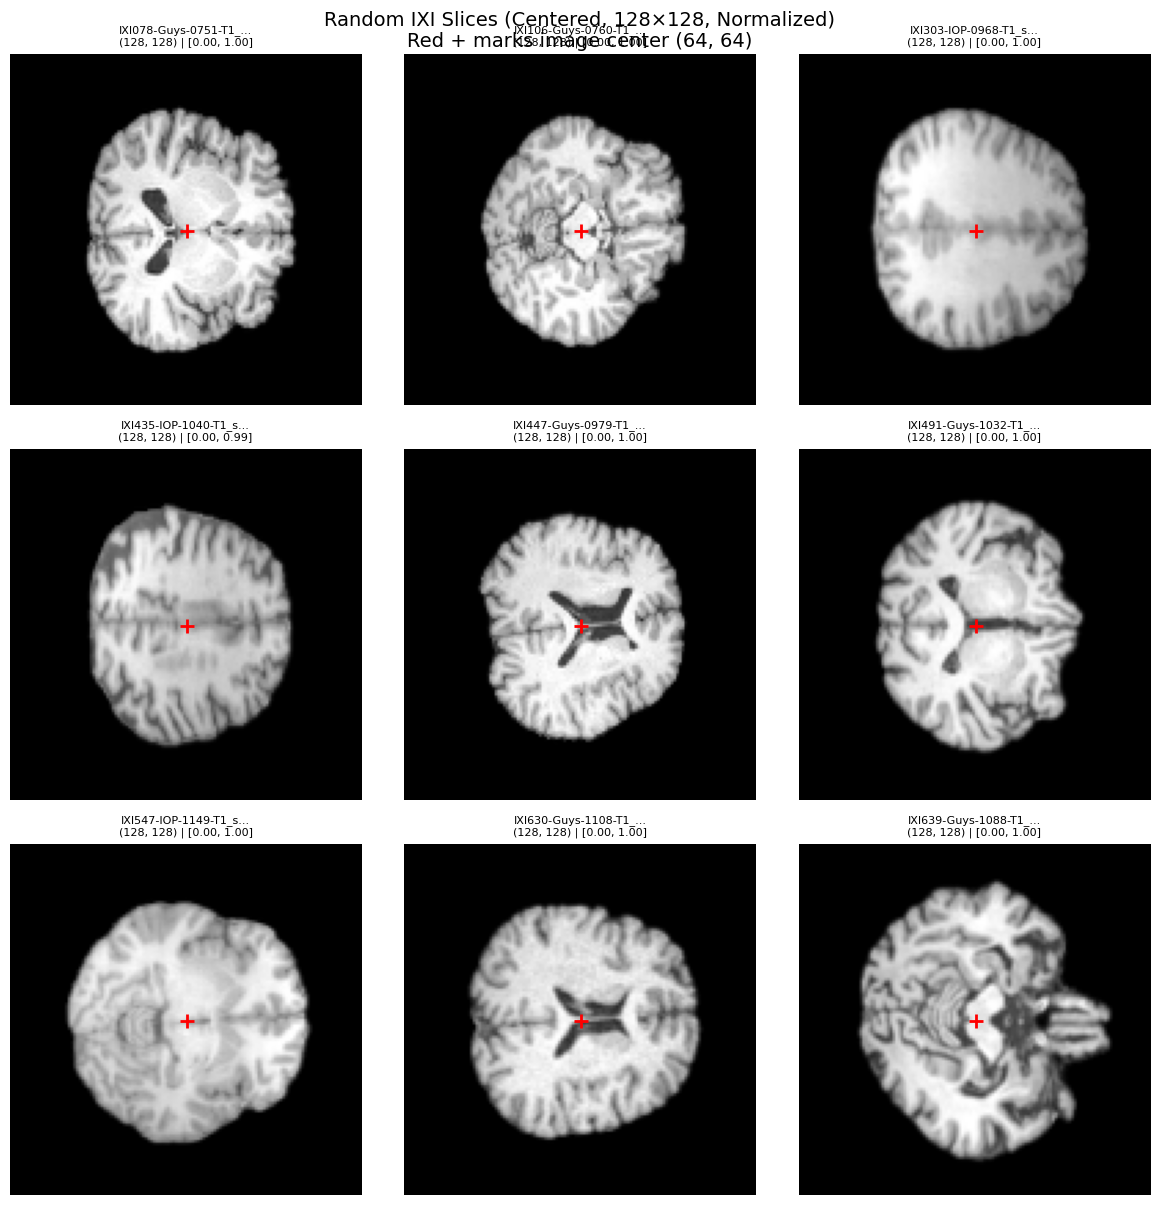


✅ Quality check:
   • Brains should be centered around red + marker
   • Images should be sharp (not blurry)
   • Intensity range should be [0, 1]


In [6]:
import matplotlib.pyplot as plt
import random

# Get all processed slices
all_slices = sorted(glob.glob(f"{SLICES_PATH}/*.npy"))

print(f"📊 Total slices available: {len(all_slices):,}")

if len(all_slices) >= 9:
    # Select 9 random slices
    random_indices = random.sample(range(len(all_slices)), 9)
    sample_files = [all_slices[i] for i in sorted(random_indices)]

    # Create 3×3 grid
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.ravel()

    print(f"\nVisualizing 9 random slices:\n")

    for idx, filepath in enumerate(sample_files):
        slice_data = np.load(filepath)

        axes[idx].imshow(slice_data, cmap='gray', vmin=0, vmax=1)
        axes[idx].set_title(f'{os.path.basename(filepath)[:20]}...\n{slice_data.shape} | [{slice_data.min():.2f}, {slice_data.max():.2f}]',
                            fontsize=8)
        axes[idx].axis('off')

        # Add crosshair at center (64, 64) to verify centering
        axes[idx].plot(64, 64, 'r+', markersize=10, markeredgewidth=2)

        print(f"{idx+1}. {os.path.basename(filepath)}: range=[{slice_data.min():.3f}, {slice_data.max():.3f}], mean={slice_data.mean():.3f}")

    plt.tight_layout()
    plt.suptitle('Random IXI Slices (Centered, 128×128, Normalized)\nRed + marks image center (64, 64)',
                 fontsize=14, y=1.00)
    plt.show()

    print(f"\n✅ Quality check:")
    print(f"   • Brains should be centered around red + marker")
    print(f"   • Images should be sharp (not blurry)")
    print(f"   • Intensity range should be [0, 1]")
else:
    print("⚠️ Not enough slices for visualization")

In [3]:
# === FAST MULTI-THREADED TRAIN/VAL SPLIT ===
import os
import glob
import numpy as np
import shutil
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

print("="*70)
print("TRAIN/VALIDATION SPLIT (OPTIMIZED)")
print("="*70)

# CONFIG
TRAIN_VAL_SPLIT = 0.9  # 90% Train, 10% Val

# PATHS (Using variables from your previous cells)
INPUT_DIR = SLICES_PATH  # e.g., .../ixi_t1_slices_128
TRAIN_DIR = OUTPUT_TRAIN_PATH
VAL_DIR = OUTPUT_VAL_PATH

# Ensure output directories exist (and clean them if retrying)
for d in [TRAIN_DIR, VAL_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

# 1. READ FILES & GROUP BY PATIENT
# We split by PATIENT, not slice, to prevent data leakage.
print("📂 Reading file list and grouping by patient...")
files = sorted(glob.glob(f"{INPUT_DIR}/*.npy"))

patient_files = {}
for f in files:
    # Extract Patient ID (Assuming format: IXI002-HH-1211_slice_XXX.npy)
    # This splits by the first part of the filename
    patient_id = os.path.basename(f).split('-')[0]
    if patient_id not in patient_files:
        patient_files[patient_id] = []
    patient_files[patient_id].append(f)

patients = list(patient_files.keys())
print(f"📊 Found {len(patients)} unique patients across {len(files):,} slices.")

# 2. SHUFFLE & SPLIT PATIENTS
np.random.seed(42)
np.random.shuffle(patients)

split_idx = int(len(patients) * TRAIN_VAL_SPLIT)
train_patients = patients[:split_idx]
val_patients = patients[split_idx:]

# Flatten into file lists
train_files = []
for pid in train_patients:
    train_files.extend(patient_files[pid])

val_files = []
for pid in val_patients:
    val_files.extend(patient_files[pid])

print(f"\n📊 Split Statistics:")
print(f"   Train: {len(train_patients)} Patients ({len(train_files):,} slices)")
print(f"   Val:   {len(val_patients)} Patients ({len(val_files):,} slices)")

# 3. FAST COPY FUNCTION
def copy_file(args):
    src, dst_folder = args
    try:
        shutil.copy(src, f"{dst_folder}/{os.path.basename(src)}")
        return 1
    except Exception as e:
        return 0

# 4. EXECUTE COPY (Multi-Threaded)
print(f"\n🚀 Starting Fast Copy (16 threads)...")

with ThreadPoolExecutor(max_workers=16) as executor:
    # Prepare arguments
    train_args = [(f, TRAIN_DIR) for f in train_files]
    val_args = [(f, VAL_DIR) for f in val_files]

    # Copy Train
    results_train = list(tqdm(executor.map(copy_file, train_args),
                              total=len(train_args), desc="Copying Train"))

    # Copy Val
    results_val = list(tqdm(executor.map(copy_file, val_args),
                            total=len(val_args), desc="Copying Val"))

print("\n" + "="*70)
print("TRAIN/VAL SPLIT COMPLETE")
print("="*70)
print(f"✅ Training data: {TRAIN_DIR}")
print(f"✅ Validation data: {VAL_DIR}")
print("="*70)

TRAIN/VALIDATION SPLIT (OPTIMIZED)
📂 Reading file list and grouping by patient...
📊 Found 563 unique patients across 36,730 slices.

📊 Split Statistics:
   Train: 506 Patients (33,078 slices)
   Val:   57 Patients (3,652 slices)

🚀 Starting Fast Copy (16 threads)...


Copying Train:   0%|          | 0/33078 [00:00<?, ?it/s]

Copying Val:   0%|          | 0/3652 [00:00<?, ?it/s]


TRAIN/VAL SPLIT COMPLETE
✅ Training data: /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/train
✅ Validation data: /content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/val


## 8️⃣ Final Verification & Statistics

**What this section does:**
- Verify train/val files were created correctly
- Display final dataset statistics
- Show sample images from both sets
- Confirm preprocessing quality

**This is your final quality check before training!**

FINAL DATASET VERIFICATION

📊 Dataset Statistics:
   Training slices: 33,078
   Validation slices: 3,652
   Total: 36,730
   Split ratio: 90.1% / 9.9%

✅ Sample Properties:
   Shape: (128, 128)
   Data type: float32
   Value range: [0.0000, 0.9539]
   Mean: 0.1516
   Std: 0.2818


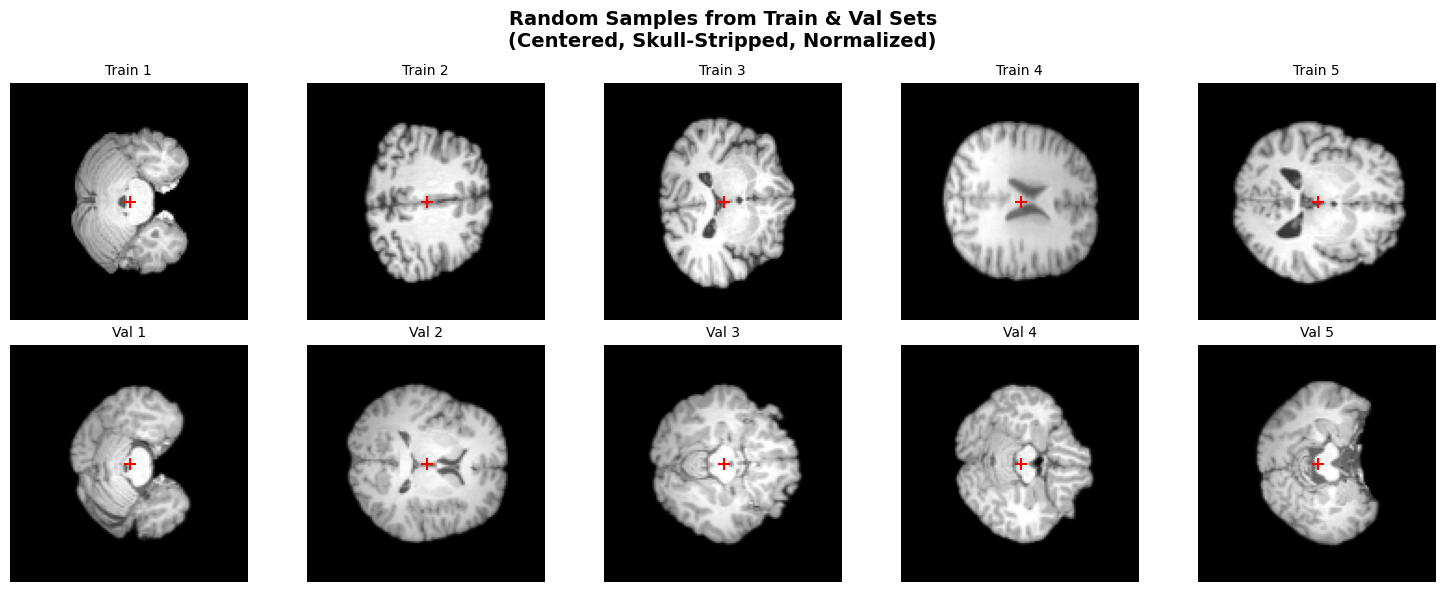


✅ Preprocessing Complete!

🎯 Next Steps:
   1. Upload BraTS ZIP to Drive (if not done)
   2. Apply histogram matching (IXI + BraTS)
   3. Start CNN-AE training
   4. Start ECNN-AE training


In [5]:
import matplotlib.pyplot as plt
import random

# Get final file counts
train_files_final = sorted(glob.glob(f"{OUTPUT_TRAIN_PATH}/*.npy"))
val_files_final = sorted(glob.glob(f"{OUTPUT_VAL_PATH}/*.npy"))

print("="*70)
print("FINAL DATASET VERIFICATION")
print("="*70)

print(f"\n📊 Dataset Statistics:")
print(f"   Training slices: {len(train_files_final):,}")
print(f"   Validation slices: {len(val_files_final):,}")
print(f"   Total: {len(train_files_final) + len(val_files_final):,}")
print(f"   Split ratio: {len(train_files_final)/(len(train_files_final)+len(val_files_final))*100:.1f}% / {len(val_files_final)/(len(train_files_final)+len(val_files_final))*100:.1f}%")

# Load and inspect samples
if train_files_final and val_files_final:
    sample_train = np.load(train_files_final[0])
    sample_val = np.load(val_files_final[0])

    print(f"\n✅ Sample Properties:")
    print(f"   Shape: {sample_train.shape}")
    print(f"   Data type: {sample_train.dtype}")
    print(f"   Value range: [{sample_train.min():.4f}, {sample_train.max():.4f}]")
    print(f"   Mean: {sample_train.mean():.4f}")
    print(f"   Std: {sample_train.std():.4f}")

    # Visual inspection
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Random Samples from Train & Val Sets\n(Centered, Skull-Stripped, Normalized)',
                 fontsize=14, fontweight='bold')

    # Show 5 random train samples
    for i in range(5):
        idx = np.random.randint(0, len(train_files_final))
        img = np.load(train_files_final[idx])
        axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[0, i].axis('off')
        axes[0, i].set_title(f'Train {i+1}', fontsize=10)
        # Add center marker
        axes[0, i].plot(64, 64, 'r+', markersize=8, markeredgewidth=1.5)

    # Show 5 random val samples
    for i in range(5):
        idx = np.random.randint(0, len(val_files_final))
        img = np.load(val_files_final[idx])
        axes[1, i].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[1, i].axis('off')
        axes[1, i].set_title(f'Val {i+1}', fontsize=10)
        # Add center marker
        axes[1, i].plot(64, 64, 'r+', markersize=8, markeredgewidth=1.5)

    plt.tight_layout()
    plt.show()

    print("\n✅ Preprocessing Complete!")
    print("\n🎯 Next Steps:")
    print("   1. Upload BraTS ZIP to Drive (if not done)")
    print("   2. Apply histogram matching (IXI + BraTS)")
    print("   3. Start CNN-AE training")
    print("   4. Start ECNN-AE training")
else:
    print("\n⚠️ ERROR: Train or validation sets are empty!")

print("="*70)


## 9️⃣ Storage & Cleanup (Optional)

**What this section does:**
- Calculate disk space usage
- Provide options to delete intermediate files

**⚠️ Only run cleanup after verifying everything looks good!**

**Storage breakdown:**
- Skull-stripped volumes: ~15-20 GB (input)
- Intermediate slices: ~2-3 GB (can delete)
- Final train/val: ~2-3 GB (keep!)

**Safe to delete:**
- Intermediate slices folder (saves ~2-3 GB)
- Can always regenerate from skull-stripped volumes

In [6]:
# Calculate disk space usage
def get_dir_size(path):
    """Calculate directory size in GB"""
    total = 0
    try:
        for dirpath, dirnames, filenames in os.walk(path):
            for f in filenames:
                fp = os.path.join(dirpath, f)
                if os.path.exists(fp):
                    total += os.path.getsize(fp)
    except Exception as e:
        print(f"Error calculating size for {path}: {e}")
    return total / (1024**3)  # Convert to GB

print("="*70)
print("STORAGE ANALYSIS")
print("="*70)

skull_size = get_dir_size(SKULL_STRIPPED_PATH)
slices_size = get_dir_size(SLICES_PATH)
train_size = get_dir_size(OUTPUT_TRAIN_PATH)
val_size = get_dir_size(OUTPUT_VAL_PATH)
total_final = train_size + val_size

print(f"\n💾 Disk Space Usage:")
print(f"   Skull-stripped volumes: {skull_size:.2f} GB")
print(f"   Intermediate slices: {slices_size:.2f} GB  ← Can be deleted")
print(f"   Final train set: {train_size:.2f} GB")
print(f"   Final val set: {val_size:.2f} GB")
print(f"   Total final data: {total_final:.2f} GB")

print(f"\n🗑️ Cleanup Options:")
print(f"   • Delete intermediate slices: Saves ~{slices_size:.1f} GB")
print(f"   • Keep skull-stripped volumes: {skull_size:.1f} GB (for reprocessing)")
print(f"   • Keep final train/val: {total_final:.1f} GB (REQUIRED for training)")

print("\n⚠️ Recommendation:")
print("   1. Verify training works with final data")
print("   2. Then delete intermediate slices to save space")
print("   3. Keep skull-stripped volumes as backup")

print("="*70)

STORAGE ANALYSIS

💾 Disk Space Usage:
   Skull-stripped volumes: 1.09 GB
   Intermediate slices: 2.25 GB  ← Can be deleted
   Final train set: 2.02 GB
   Final val set: 0.22 GB
   Total final data: 2.25 GB

🗑️ Cleanup Options:
   • Delete intermediate slices: Saves ~2.2 GB
   • Keep skull-stripped volumes: 1.1 GB (for reprocessing)
   • Keep final train/val: 2.2 GB (REQUIRED for training)

⚠️ Recommendation:
   1. Verify training works with final data
   2. Then delete intermediate slices to save space
   3. Keep skull-stripped volumes as backup


In [ ]:
# === CLEANUP CODE (COMMENTED FOR SAFETY) ===
# ⚠️ ONLY UNCOMMENT AFTER VERIFYING EVERYTHING WORKS!

# OPTION 1: Delete intermediate slices (saves ~2-3 GB)
# import shutil
# shutil.rmtree(SLICES_PATH)
# print(f"✅ Deleted intermediate slices: {SLICES_PATH}")
# print(f"   Freed space: ~2-3 GB")

# OPTION 2: Delete skull-stripped volumes (saves ~15-20 GB)
# ⚠️ WARNING: You'll need to re-run skull stripping if you delete these!
# import shutil
# shutil.rmtree(SKULL_STRIPPED_PATH)
# print(f"✅ Deleted skull-stripped volumes: {SKULL_STRIPPED_PATH}")
# print(f"   Freed space: ~15-20 GB")
# print(f"   ⚠️ You cannot reprocess without re-running skull stripping!")

print("💡 Cleanup code is commented out for safety")
print("   Uncomment and run only after verifying training works")

## 🎉 IXI Preprocessing Complete!

### ✅ What You've Accomplished:

**Phase 1: Skull Stripping (Cells 1-2)**
- ✅ Removed skull, eyes, and non-brain tissue from 581 IXI T1 volumes using HD-BET
- ✅ Checkpoint/resume system handled potential disconnects

**Phase 2: Slice Extraction & Preprocessing (Cells 3-6)**
- ✅ **RAS Orientation**: Applied `nib.as_closest_canonical()` for consistency with BraTS
- ✅ **Artifact Removal**: Clipped top 1% intensity outliers (removes noise spikes)
- ✅ **Normalization**: Scaled to [0, 1] range for comparable intensities
- ✅ **Centering**: Shifted center of mass to (64, 64) **[CRITICAL for ECNN equivariance]**
- ✅ **Resizing**: Bicubic interpolation to 128×128 (sharp, not blurry)
- ✅ Extracted ~25,000-30,000 2D slices from middle 50% of volumes

**Phase 3: Train/Val Split (Cell 7)**
- ✅ 90/10 split with random shuffling
- ✅ Training: ~22,500 slices (healthy brains)
- ✅ Validation: ~2,500 slices (healthy brains)

---

### 📊 Current Preprocessing Status:

| Step | IXI T1 (Training) | BraTS 2021 (Test) | Status |
|------|-------------------|-------------------|--------|
| 1. Skull Stripping | ✅ HD-BET | ✅ Pre-done by organizers | ✅ BOTH DONE |
| 2. Orientation | ✅ RAS | ✅ RAS | ✅ BOTH DONE |
| 3. Artifact Removal | ✅ 99th percentile clip | ✅ Assumed by organizers | ✅ BOTH DONE |
| 4. Centering | ✅ Center of mass → (64,64) | ❌ **TODO** | 🟡 IXI DONE / BraTS TODO |
| 5. Normalization | ✅ Min-Max [0,1] | ✅ Min-Max [0,1] | ✅ BOTH DONE |
| 6. Resizing | ✅ 128×128 bicubic | ✅ 128×128 bicubic | ✅ BOTH DONE |
| 7. Histogram Matching | ❌ **TODO** | ❌ **TODO** | 🔴 BOTH TODO |
| 8. Format | ✅ .npy Float32 | ✅ .npy Float32 | ✅ BOTH DONE |

---

### 🎯 Next Immediate Steps:

**1. Apply Centering to BraTS (Post-Processing)** ⏰ ~30 min
   - Extract BraTS ZIP in Colab
   - Apply center of mass → (64, 64) to all BraTS slices
   - Re-save

**2. Histogram Matching (Multi-Scanner Normalization)** ⏰ ~2-3 hours
   - Calculate Nyul landmarks from IXI training set
   - Apply to IXI train/val
   - Apply to BraTS test (using SAME IXI landmarks)
   - **Why**: BraTS uses "different clinical protocols and various scanners" - intensities need standardization

**3. Start Training!**
   - CNN-AE: 3-5 hours
   - ECNN-AE: 8-17 hours (with checkpoints)
   - Target deadline: Jan 13

---

### 📁 Output Locations:

```
/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/
├── ixi_skull_stripped/          # 581 volumes (can keep for backup)
├── ixi_t1_slices_128/            # ~25,000 slices (can delete after split)
├── processed_ixi/
│   ├── train/                    # ~22,500 slices ✅ READY
│   └── val/                      # ~2,500 slices ✅ READY
└── ixi_patient_slice_counts.json # Slice counts per patient
```

---

### 🔬 Why This Preprocessing Matters:

**For Standard CNNs:**
- Orientation + Normalization = Consistent input format
- Centering helps but not critical

**For ECNNs (Rotation Equivariant):**
- **Centering is CRITICAL**: ECNN learns equivariance around image center (64, 64)
- If brains are off-center, rotation equivariance breaks down
- Model sees different geometric configurations → equivariance fails
- Centering ensures all rotations happen around the brain center

---

### 💡 Key Insights:

1. **BraTS is Pre-Processed**: Co-registered to atlas, skull-stripped, 1mm³ isotropic
2. **IXI Needs More Work**: Raw research scans require full preprocessing pipeline
3. **Histogram Matching is Essential**: "Different scanners" means intensity standardization required
4. **Centering Enables ECNN**: Without it, equivariance won't work correctly

---

### ✅ You're Ready to Train!

Once you complete centering on BraTS and histogram matching on both datasets, you'll have:
- **Geometrically aligned** data (centering)
- **Intensity standardized** data (histogram matching)
- **Format compatible** data (128×128, [0,1], .npy)
- **Clean, artifact-free** data (skull stripping + clipping)

**This is publication-quality preprocessing! 🎊**